# BANKING77: a small LLM scoring demo

We extend notebook 01 from three hand-written intents to **all 77 BANKING77 intents**, using the same local Qwen model. The goal is simple: score five real requests, compare summing and averaging token log-probabilities, and look at the answers.

This is a demonstration, not a benchmark or a configuration-selection experiment. We use training requests and do not evaluate the official test set.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import mlx.core as mx
import numpy as np
from mlx_lm import load

from conformal_selective_prediction.data import load_banking77
from _scoring import score_candidates

/Users/enzocanonero/miniforge3/envs/llm-scorekit/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Pick five training requests

We reuse the project's data loader and take a small random sample. Every request will be scored against all 77 intents, not just the labels appearing in these five examples.

In [7]:
data = load_banking77(Path("../../data/raw/banking77"))
class_names = data.class_names

rng = np.random.default_rng(42)
sample_indices = rng.choice(len(data.train.texts), size=5, replace=False)
requests = data.train.texts[sample_indices]
true_labels = data.train.labels[sample_indices]

print(requests[0])
print("True intent:", class_names[true_labels[0]])
print()

print(requests[1])
print("True intent:", class_names[true_labels[1]])
print()

print(requests[2])
print("True intent:", class_names[true_labels[2]])
print()

print(requests[3])
print("True intent:", class_names[true_labels[3]])
print()

print(requests[4])
print("True intent:", class_names[true_labels[4]])
print()

I need to transfer money into this account from my other bank account.
True intent: transfer_into_account

Declined, transfer not completed.
True intent: declined_transfer

is it possible to cancel transactions?
True intent: cancel_transfer

After inputting the wrong pin too many times, can you now help me unblock my pin?
True intent: pin_blocked

What method do you use for the exchange rate?
True intent: exchange_rate



## 2. Load Qwen and list the possible answers

The prompt contains the intent names and asks for one answer. We also score the end-of-response token, so each candidate represents a complete reply rather than just its beginning.

In [8]:
# Keep unused MLX buffers small on the 16 GB Mac.
mx.set_cache_limit(512 * 1024**2)

model, tokenizer = load(
    "mlx-community/Qwen3-4B-Instruct-2507-4bit",
    revision="50d427756c6b1b2fe0c0a10f67fbda1fc8e82c1b",
)

Fetching 11 files: 100%|█████████████████████| 11/11 [00:00<00:00, 1781.98it/s]


In [19]:
instructions = (
    "Classify the banking customer request.\n"
    "Choose one of these intents and return only its name:\n" + "\n".join(class_names)
)


# Format one customer request for Qwen.
def build_prompt(request: str) -> str:
    messages = [
        {"role": "system", "content": instructions},
        {"role": "user", "content": request},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )


candidate_ids = []
for i, label in enumerate(class_names):
    label_ids = tokenizer.encode(label, add_special_tokens=False)
    candidate_ids.append(label_ids + [tokenizer.eos_token_id])
    token_pieces = tokenizer.convert_ids_to_tokens(label_ids)
    if  i < 5:
        print(label)
        print("Tokens:", token_pieces)
        print("Token count:", len(token_pieces))
        print()
        
token_counts = np.array([len(ids) for ids in candidate_ids])

card_arrival
Tokens: ['card', '_arr', 'ival']
Token count: 3

card_linking
Tokens: ['card', '_link', 'ing']
Token count: 3

exchange_rate
Tokens: ['exchange', '_rate']
Token count: 2

card_payment_wrong_exchange_rate
Tokens: ['card', '_payment', '_wrong', '_exchange', '_rate']
Token count: 5

extra_charge_on_statement
Tokens: ['extra', '_charge', '_on', '_statement']
Token count: 4



## 3. Score each request

The short helper in [_scoring.py](_scoring.py) adds the token log-probabilities as in notebook 01. It processes the shared prompt once, then gives each candidate its own copy of that internal state. This avoids repeating the same work 77 times. There is no training, answer generation or saving to disk.

In [ ]:
score_rows = []
start = perf_counter()

for i, request in enumerate(requests):
    prompt = build_prompt(str(request))
    prompt_ids = tokenizer.encode(prompt, add_special_tokens=False)
    scores = score_candidates(model, prompt_ids, candidate_ids)
    score_rows.append(scores)
    
log_scores = np.asarray(score_rows)
print(f"Scoring time: {(perf_counter() - start) / 60:.1f} minutes")

## 4. Compare sum and mean

- **Sum** scores the complete response by adding its token log-probabilities.
- **Mean** divides that sum by the number of scored tokens, including the end token. It reduces the direct penalty for longer names, but is not automatically a better rule.

We count how often the true intent ranks first or within the first three. With only five examples, these counts describe the demo—not the model's general accuracy.

In [6]:
mean_scores = log_scores / token_counts
comparisons = {"Sum": log_scores, "Mean": mean_scores}

for name, scores in comparisons.items():
    ranking = np.argsort(-scores, axis=1)
    first_correct = ranking[:, 0] == true_labels
    top_three_correct = np.any(ranking[:, :3] == true_labels[:, None], axis=1)
    print(
        f"{name}: first choice {first_correct.sum()}/{len(requests)}, "
        f"top three {top_three_correct.sum()}/{len(requests)}"
    )

Sum: first choice 5/5, top three 5/5
Mean: first choice 5/5, top three 5/5


## 5. Look at one request

Change `request_index` to inspect another example. The plots show the five highest-weight intents under each rule.

The softmax converts the scores into relative weights across all 77 candidates. A weight near one means an answer dominates the alternatives; it is **not a calibrated probability that the answer is correct**.

In [7]:
# Turn one request's scores into relative candidate weights.
def relative_weights(scores: np.ndarray) -> np.ndarray:
    shifted_scores = scores - scores.max()
    weights = np.exp(shifted_scores)
    return weights / weights.sum()


request_index = 0
print("Request:", requests[request_index])
print("True intent:", class_names[true_labels[request_index]])

Request: I need to transfer money into this account from my other bank account.
True intent: transfer_into_account


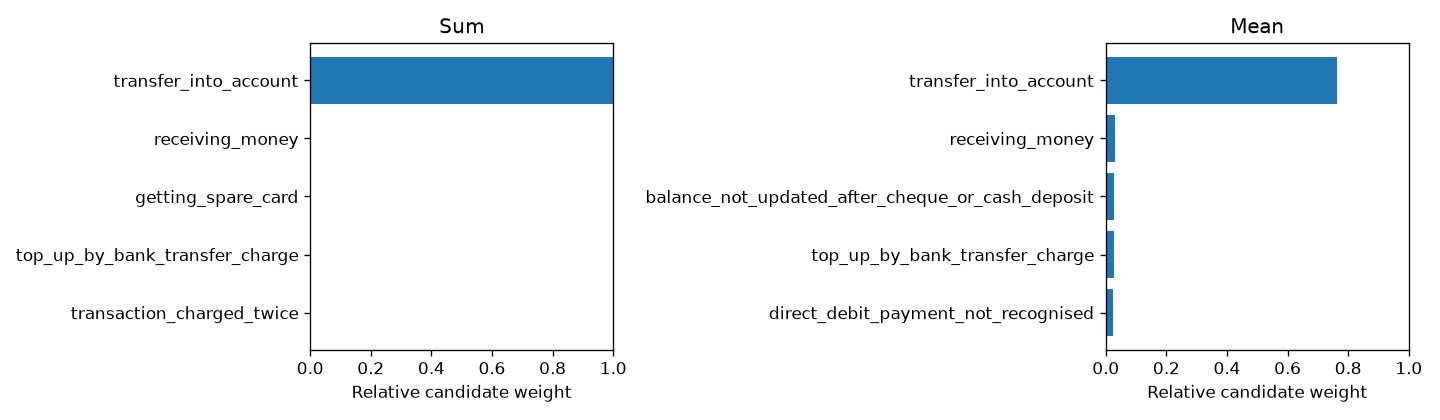

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

for axis, (name, scores) in zip(axes, comparisons.items()):
    weights = relative_weights(scores[request_index])
    top_indices = np.argsort(-weights)[:5]
    intent_names = [class_names[index] for index in top_indices]

    axis.barh(intent_names, weights[top_indices])
    axis.invert_yaxis()
    axis.set_xlim(0, 1)
    axis.set_title(name)
    axis.set_xlabel("Relative candidate weight")

fig.tight_layout()
plt.show()

## Takeaway

Both rules pick the correct intent for these five examples. In the request shown, averaging spreads weight across more alternatives but leaves the first choice unchanged. Five successes do not establish general accuracy or make the weights calibrated probabilities.

This notebook only demonstrates the scoring workflow. A proper evaluation of accuracy, calibration and automatic routing belongs in a separate experiment.